<div class="alert alert-success"><h1>Deep Learning with Python using Keras</h1></div>

Deep learning has revolutionized the field of machine learning, enabling significant advancements in areas such as computer vision, natural language processing, and speech recognition. In this tutorial, we'll embark on our deep learning journey by learning how to design and build a deep learning model using Keras, a user-friendly and high-level neural networks API, written in Python and capable of running on top of TensorFlow. Keras allows for easy and fast prototyping of deep learning models.

## Learning Objectives
By the end of this tutorial, you will:
+ Understand the basics of Keras.
+ Know how to load and preprocess data.
+ Know how to define a deep learning model in Keras.
+ Understand how to compile a Keras model.
+ Know how to train and save a model.

## Prerequisites
Before we begin, ensure you have:

+ Basic knowledge of Python programming (variables, functions, classes).
+ Familiarity with fundamental machine learning concepts (datasets, training/testing, overfitting).
+ A Python (version 3.x) environment with the `tensorflow`, `keras`, `numpy`, and `matplotlib` packages installed.

<div class="alert alert-success"><h2>1. Import the Libraries</h2></div>

To start, we'll import the necessary libraries that we'll use throughout this tutorial.

In [3]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1781296159.168740   47310 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781296159.193476   47310 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781296160.887052   47310 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781296164.923218   47310 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

The libraries we imported are:
+ **numpy:** A fundamental package for scientific computing in Python, used for handling arrays and mathematical functions.
+ **tensorflow:** An open-source platform for machine learning developed by Google.
+ **keras:** A high-level API for building and training deep learning models, integrated within TensorFlow.
+ **layers:** A module in Keras containing various types of neural network layers.

To ensure reproducibility of my code, so you obtain the same results as my example, I will set a random initialization seed using the `keras.utils.set_random_seed()` function. This will make the weights and biases initialized during the training process deterministic, ensuring consistent results across different runs. However, in practice, setting a seed is not typically necessary.

In [4]:
keras.utils.set_random_seed(1234)

<div class="alert alert-success"><h2>2. Load the Data</h2></div>

For this tutorial, we'll use the **MNIST dataset**, a classic dataset in the machine learning community. It consists of 70,000 grayscale images of handwritten digits ranging from 0 to 9. Each image is 28x28 pixels, and the dataset is divided into 60,000 training images and 10,000 testing images. Our goal will be to develop a model that learns to correctly identify a handritten digit given the image.

Keras provides easy access to the MNIST dataset via its datasets module.

In [5]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

The `keras.datasets.minist.load_data()` function returns four datasets:
+ **train_images:** A numpy array of training images.
+ **train_labels:** A numpy array of training labels.
+ **test_images:** A numpy array of testing images.
+ **test_labels:** A numpy array of testing labels.

Let's take a moment to understand the data we're working with. We start by getting the shape of the training and test sets.

In [6]:
print("Training data shape:", train_images.shape, train_labels.shape)
print("Testing data shape:", test_images.shape, test_labels.shape)
# train_images[0]

Training data shape: (60000, 28, 28) (60000,)
Testing data shape: (10000, 28, 28) (10000,)


The output tells us that:
+ The training data consists of 60,000 images, each of size 28x28 pixels.
+ The test data consists of 10,000 images, each of size 28x28 pixels.

Visualizing some samples can provide further intuition about the dataset. Let's display the first 5 images in the training set along with their associated labels.

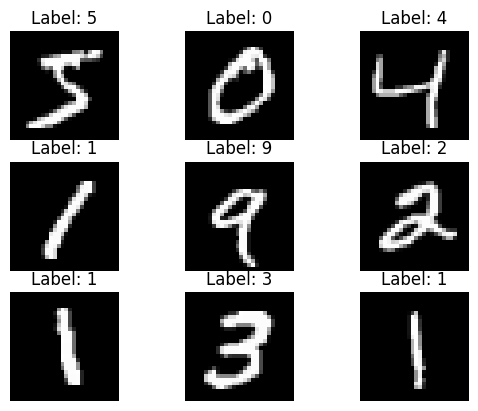

In [7]:
import matplotlib.pyplot as plt

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

<div class="alert alert-success"><h2>3. Preprocess the Data</h2></div>

Before feeding the data into our deep learning model, we need to preprocess it to ensure optimal performance. Neural networks in Keras expect the input data to be in a specific shape. We're going to build a simple feedforward neural network (also known as a multilayer perceptron). This type of network expects the incoming data as a vector.

This means we need to flatten the 28x28 images into vectors of size 784 (i.e. 28 $\times$ 28).

In [10]:
train_images = train_images.reshape(60000, 28 * 28)
test_images = test_images.reshape(10000, 28 * 28)

Let's get the shape of the training and test sets again.

In [11]:
print('Train data shape:', train_images.shape, train_labels.shape)
print('Test data shape:', test_images.shape, test_labels.shape)

Train data shape: (60000, 784) (60000,)
Test data shape: (10000, 784) (10000,)


Now, `train_images` and `test_images` have shapes (60000, 784) and (10000, 784), respectively.

Pixel values in images range from 0 to 255. Neural networks perform better when input values are scaled to a smaller range, typically between 0 and 1. To accommodate this, we convert the data type of the image pixels to float32 and normalize the values to fall within 0 and 1 by dividing them by 255.

In [12]:
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

The label values associated with each image are integers from 0 to 9. For multi-class classification, it's standard to convert these labels into one-hot encoded vectors. One-hot encoding involves representing categorical variables as binary vectors. For instance, label '0' becomes [1, 0, 0, 0, 0, 0, 0, 0, 0, 0] and label '9' becomes [0, 0, 0, 0, 0, 0, 0, 0, 0, 1].

In [13]:
num_classes = 10
train_labels = keras.utils.to_categorical(train_labels, num_classes)
test_labels = keras.utils.to_categorical(test_labels, num_classes)

Now, `train_labels` and `test_labels` are matrices of shape (60000, 10) and (10000, 10), respectively.